In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta,date

In [2]:
data=pd.read_csv('modified_merged_ecommerce_data.csv')

In [3]:
data=data.drop(columns=['Unnamed: 0'])

In [4]:
data.head()

,customer_id,signup_date,age,gender,order_date,amount,status,device,country,event,currency
0,C4160,2023-10-17,30.0,0.0,2024-01-28,99.975488,completed,mobile,US,click,USD
1,C4160,2023-10-17,30.0,0.0,2024-12-26,-264.571496,refunded,desktop,US,click,USD
2,C2075,2022-01-22,28.0,0.0,2022-10-20,220.348791,completed,mobile,US,purchase,USD
3,C285,2023-02-21,28.0,1.0,2023-06-08,-92.077224,refunded,mobile,UK,view,USD
4,C4934,2022-05-13,30.0,0.0,2022-07-24,-177.631072,refunded,desktop,US,purchase,USD


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39753 entries, 0 to 39752
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  39753 non-null  object 
 1   signup_date  39753 non-null  object 
 2   age          39753 non-null  float64
 3   gender       39753 non-null  float64
 4   order_date   39753 non-null  object 
 5   amount       39753 non-null  float64
 6   status       39753 non-null  object 
 7   device       39753 non-null  object 
 8   country      39753 non-null  object 
 9   event        39753 non-null  object 
 10  currency     39753 non-null  object 
dtypes: float64(3), object(8)
memory usage: 3.3+ MB


In [6]:
data_sub=data.copy()

In [7]:
data_sub.describe()

,age,gender,amount
count,39753.000000,39753.000000,39753.000000
mean,27.668126,0.509496,-3.270475
std,2.070226,0.499916,195.235080
min,25.000000,0.000000,-694.864562
25%,25.000000,0.000000,-132.658772
50%,28.000000,1.000000,-3.489788
75%,30.000000,1.000000,130.874975
max,30.000000,1.000000,667.992667


In [8]:
data_sub['order_date']=pd.to_datetime(data_sub['order_date'])
data_sub['signup_date']=pd.to_datetime(data_sub['signup_date'])

In [9]:
data_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39753 entries, 0 to 39752
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  39753 non-null  object        
 1   signup_date  39753 non-null  datetime64[ns]
 2   age          39753 non-null  float64       
 3   gender       39753 non-null  float64       
 4   order_date   39753 non-null  datetime64[ns]
 5   amount       39753 non-null  float64       
 6   status       39753 non-null  object        
 7   device       39753 non-null  object        
 8   country      39753 non-null  object        
 9   event        39753 non-null  object        
 10  currency     39753 non-null  object        
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 3.3+ MB


In [10]:
data_sub.shape

(39753, 11)

In [11]:
latest_order_date=data_sub['order_date'].max()
latest_order_date

Timestamp('2025-11-30 00:00:00')

**Aggregating data per customer**

In [12]:
customer_df=data_sub.groupby('customer_id').agg({
    'order_date': ['max','count'],
    'amount': ['sum','mean']
})
customer_df.columns=['last_purchase','frequency','monetary','avg_order_value']
customer_df=customer_df.reset_index()

customer_df['recency']=(latest_order_date-customer_df['last_purchase']).dt.days
customer_df.head()

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency
0,C10,2023-08-30,1,0.567068,0.567068,823
1,C1000,2023-08-16,1,57.294811,57.294811,837
2,C1002,2024-05-24,4,-508.832267,-127.208067,555
3,C1005,2025-08-26,48,-60.088505,-1.251844,96
4,C1006,2024-02-10,1,-216.765751,-216.765751,659


In [13]:
customer_df['recency'].describe()

count    4257.000000
mean      497.236552
std       312.069331
min         0.000000
25%       243.000000
50%       445.000000
75%       705.000000
max      1389.000000
Name: recency, dtype: float64

In [14]:
customer_df['churn']=np.where(customer_df['recency']> 365,1,0)

In [15]:
customer_df.head()

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency,churn
0,C10,2023-08-30,1,0.567068,0.567068,823,1
1,C1000,2023-08-16,1,57.294811,57.294811,837,1
2,C1002,2024-05-24,4,-508.832267,-127.208067,555,1
3,C1005,2025-08-26,48,-60.088505,-1.251844,96,0
4,C1006,2024-02-10,1,-216.765751,-216.765751,659,1


In [16]:
customer_df['churn'].value_counts()

churn
1    2545
0    1712
Name: count, dtype: int64

**EDA**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

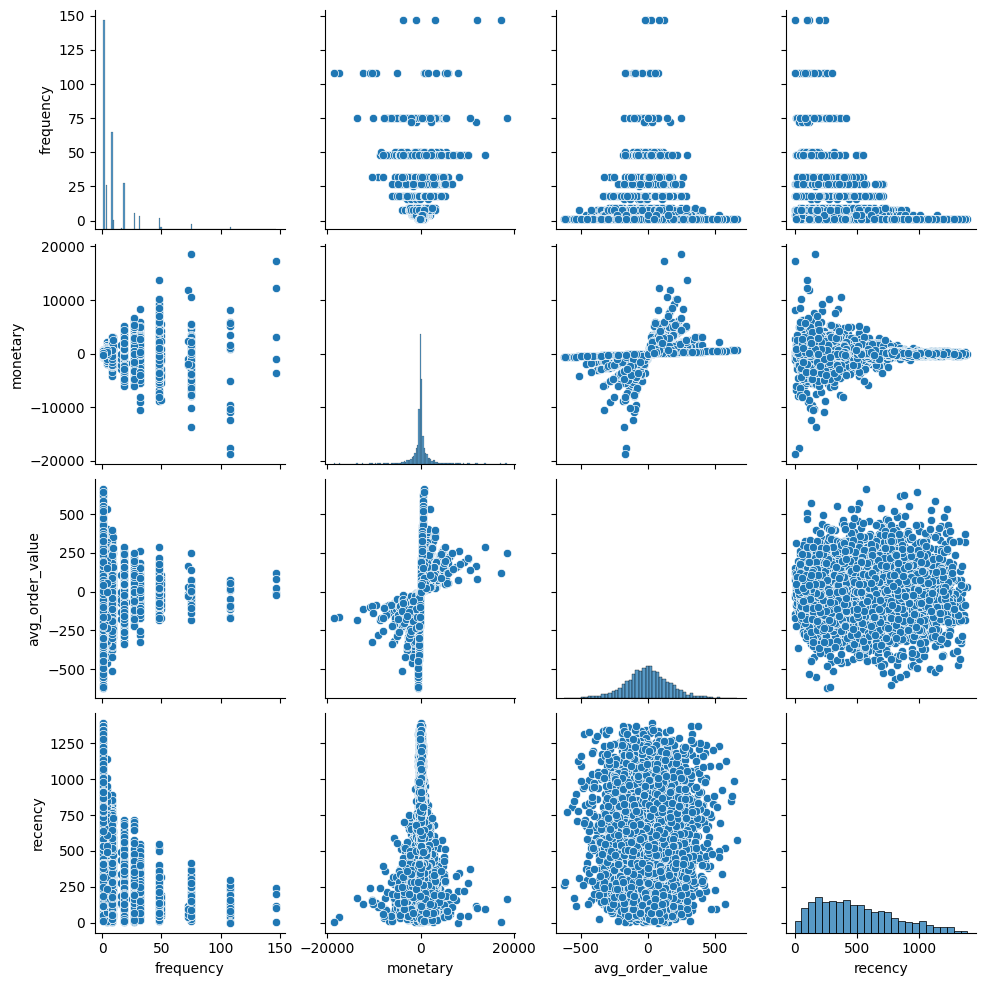

In [27]:
sns.pairplot(customer_df.drop(columns=['churn']))

<Axes: ylabel='recency'>

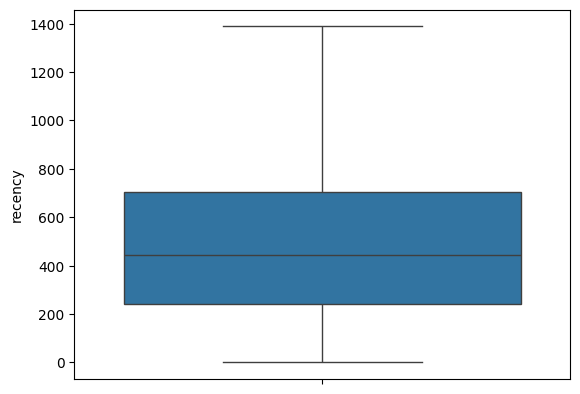

In [28]:
sns.boxplot(customer_df['recency'])

Text(0.5, 1.0, 'Distribution of Frequency feature')

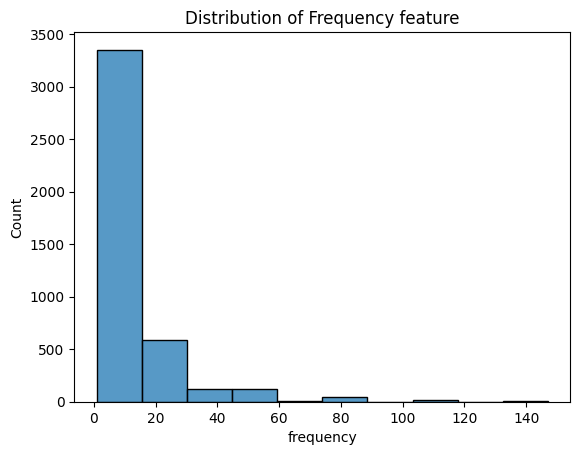

In [36]:
sns.histplot(customer_df['frequency'],bins=10)
plt.title('Distribution of Frequency feature')

Text(0.5, 1.0, 'Distribution of monetary feature')

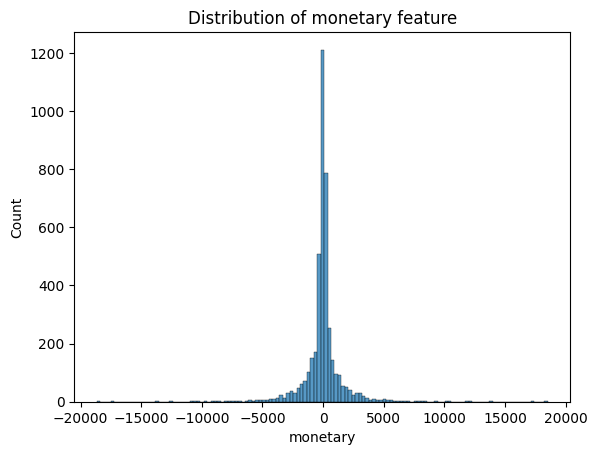

In [35]:
sns.histplot(customer_df['monetary'])
plt.title('Distribution of monetary feature')

Text(0.5, 1.0, 'Distribution of recency feature')

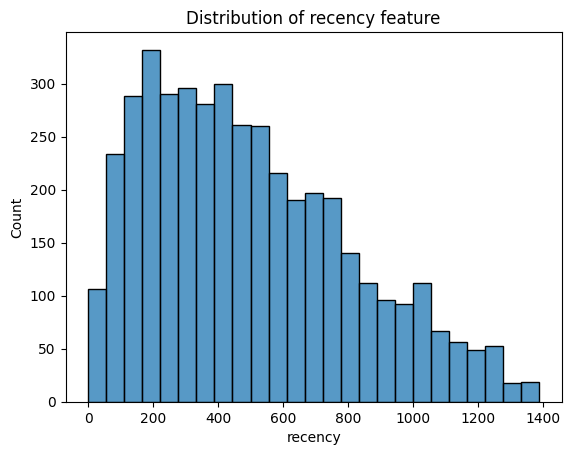

In [34]:
sns.histplot(customer_df['recency'])
plt.title('Distribution of recency feature')

Text(0.5, 1.0, 'Distribution of avg_order_value feature')

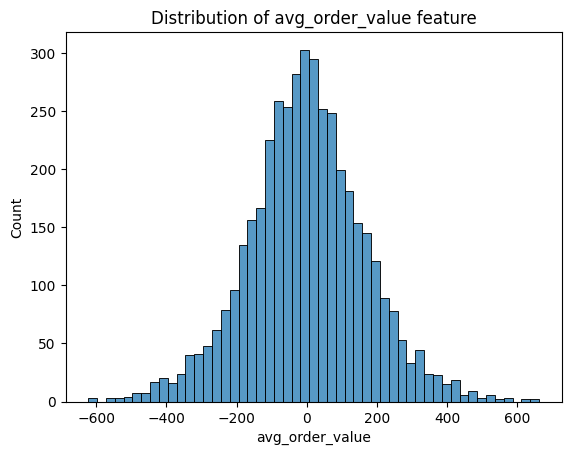

In [37]:
sns.histplot(customer_df['avg_order_value'])
plt.title('Distribution of avg_order_value feature')

**modeling**

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

x=customer_df.drop(columns=['customer_id','churn','last_purchase','recency'])
y=customer_df['churn']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.fit_transform(x_test)

lr=LogisticRegression()
lr.fit(x_train_scaled,y_train)
lr_preds=lr.predict(x_test_scaled)
lr_acc=accuracy_score(y_test,lr_preds)
lr_prec=precision_score(y_test,lr_preds)
lr_rec=recall_score(y_test,lr_preds)
lr_f1=f1_score(y_test,lr_preds)

print(classification_report(y_test,lr_preds))

results={'Model': 'Logistic Regression','Precision': lr_prec,'Recall': lr_rec, 'F1': lr_f1, 'Accuracy': lr_acc}
results=pd.DataFrame(results,index=[1])

              precision    recall  f1-score   support

           0       0.84      0.49      0.62       350
           1       0.73      0.94      0.82       502

    accuracy                           0.75       852
   macro avg       0.78      0.71      0.72       852
weighted avg       0.77      0.75      0.74       852



In [46]:
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
rf_preds=rf.predict(x_test)
rf_acc=accuracy_score(y_test,rf_preds)
rf_prec=precision_score(y_test,rf_preds)
rf_rec=recall_score(y_test,rf_preds)
rf_f1=f1_score(y_test,rf_preds)
print(classification_report(y_test,rf_preds))

rf_results={'Model': 'RandomForestClassifier','Precision': rf_prec,'Recall': rf_rec, 'F1': rf_f1, 'Accuracy': rf_acc}
rf_results=pd.DataFrame(rf_results,index=[2])
results=pd.concat([results,rf_results])

              precision    recall  f1-score   support

           0       0.56      0.57      0.57       350
           1       0.70      0.69      0.70       502

    accuracy                           0.64       852
   macro avg       0.63      0.63      0.63       852
weighted avg       0.64      0.64      0.64       852



In [47]:
results

,Model,Precision,Recall,F1,Accuracy
1,Logistic Regression,0.725309,0.936255,0.817391,0.753521
2,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192


In [20]:
nb=GaussianNB()
nb.fit(x_train,y_train)
nb_preds=nb.predict(x_test)

nb_prec=precision_score(y_test,nb_preds)
nb_rec=recall_score(y_test,nb_preds)
nb_f1=f1_score(y_test,nb_preds)
nb_acc=accuracy_score(y_test,nb_preds)
print(classification_report(y_test,nb_preds))

nb_results={'Model': 'GaussianNB','Precision': nb_prec,'Recall': nb_rec, 'F1': nb_f1, 'Accuracy': nb_acc}
nb_results=pd.DataFrame(nb_results,index=[3])
results=pd.concat([results,nb_results])

              precision    recall  f1-score   support

           0       0.81      0.51      0.63       350
           1       0.73      0.92      0.81       502

    accuracy                           0.75       852
   macro avg       0.77      0.71      0.72       852
weighted avg       0.76      0.75      0.74       852



In [21]:
results

,Model,Precision,Recall,F1,Accuracy
1,Logistic Regression,0.725309,0.936255,0.817391,0.753521
2,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192
3,GaussianNB,0.728278,0.918327,0.812335,0.750000


In [22]:
xgb=XGBClassifier(random_state=42)
xgb.fit(x_train,y_train)
xgb_preds=xgb.predict(x_test)

xgb_prec=precision_score(y_test,xgb_preds)
xgb_rec=recall_score(y_test,xgb_preds)
xgb_f1=f1_score(y_test,xgb_preds)
xgb_acc=accuracy_score(y_test,xgb_preds)
print(classification_report(y_test,xgb_preds))

xgb_results={'Model': 'XGBClassifier','Precision': xgb_prec,'Recall': xgb_rec, 'F1': xgb_f1, 'Accuracy': xgb_acc}
xgb_results=pd.DataFrame(xgb_results,index=[4])
results=pd.concat([results,xgb_results])

              precision    recall  f1-score   support

           0       0.67      0.64      0.66       350
           1       0.76      0.78      0.77       502

    accuracy                           0.73       852
   macro avg       0.72      0.71      0.71       852
weighted avg       0.72      0.73      0.72       852



In [23]:
results

,Model,Precision,Recall,F1,Accuracy
1,Logistic Regression,0.725309,0.936255,0.817391,0.753521
2,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192
3,GaussianNB,0.728278,0.918327,0.812335,0.750000
4,XGBClassifier,0.757692,0.784861,0.771037,0.725352


In [157]:
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Seems like logistic regression is the champion model: though try fine tuning the models(randomForest,XGB to see if it will outperform it!!)**

In [158]:
from sklearn.model_selection import GridSearchCV

In [159]:
params={
    'n_estimators': [100,200,300,500],
    'max_depth': [4,6,10,None],
    'min_samples_split':[2,3,4,5],
    'min_samples_leaf': [1,2,3,4]
}
scoring=['precision','recall','f1','accuracy']

In [160]:
grid_rf=GridSearchCV(
    estimator=rf,
    param_grid=params,
    scoring=scoring,
    refit='f1'
)

In [161]:
%%time
grid_rf.fit(x_train,y_train)

CPU times: user 13min 49s, sys: 1.59 s, total: 13min 51s
Wall time: 13min 51s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,"['precision', 'recall', ...]"
,n_jobs,None
,refit,'f1'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [162]:
bm_rf=grid_rf.best_estimator_
grid_rf.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [163]:
bm_rf.fit(x_train,y_train)
bm_rf_preds=grid.predict(x_test)

bm_rf_prec=precision_score(y_test,bm_rf_preds)
bm_rf_rec=recall_score(y_test,bm_rf_preds)
bm_rf_f1=f1_score(y_test,bm_rf_preds)
bm_rf_acc=accuracy_score(y_test,bm_rf_preds)

print(classification_report(y_test,bm_rf_preds))

grid_rf_results={'Model': 'RandomForestClassifier(tuned)','Precision': bm_rf_prec,'Recall': bm_rf_rec, 'F1': bm_rf_f1, 'Accuracy': bm_rf_acc}
grid_rf_results=pd.DataFrame(grid_rf_results,index=[4])
results=pd.concat([results,grid_rf_results])

              precision    recall  f1-score   support

           0       0.69      0.68      0.68       350
           1       0.78      0.79      0.78       502

    accuracy                           0.74       852
   macro avg       0.74      0.73      0.73       852
weighted avg       0.74      0.74      0.74       852



In [164]:
results

,Model,Precision,Recall,F1,Accuracy
0,Logistic Regression,0.725309,0.936255,0.817391,0.753521
1,GaussianNB,0.728278,0.918327,0.812335,0.750000
2,XGBClassifier,0.757692,0.784861,0.771037,0.725352
3,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192
4,RandomForestClassifier(tuned),0.778431,0.790837,0.784585,0.744131


In [165]:
grid_rf.best_score_

np.float64(0.7831432453596807)

**Tuning the xgb model**

In [166]:
params_grid={
    'n_estimators': [100,200,300,500,None],
    'max_depth': [4,6,10,None],
    'min_child_weight': [2,3,4,None]
}
scoring=['precision','recall','f1','accuracy']

In [167]:
grid_xgb=GridSearchCV(
    estimator=xgb,
    param_grid=params_grid,
    scoring=scoring,
    refit='f1'
)

In [168]:
%%time

grid_xgb.fit(x_train,y_train)

CPU times: user 5min 39s, sys: 3.35 s, total: 5min 42s
Wall time: 43.4 s


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'max_depth': [4, 6, ...], 'min_child_weight': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,"['precision', 'recall', ...]"
,n_jobs,None
,refit,'f1'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [169]:
bm_xgb=grid_xgb.best_estimator_
grid_xgb.best_params_

{'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 100}

In [170]:
bm_xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [171]:
bm_xgb_preds=grid_xgb.predict(x_test)

In [172]:
bm_xgb_prec=precision_score(y_test,bm_xgb_preds)
bm_xgb_rec=recall_score(y_test,bm_xgb_preds)
bm_xgb_f1=f1_score(y_test,bm_xgb_preds)
bm_xgb_acc=accuracy_score(y_test,bm_xgb_preds)

print(classification_report(y_test,bm_xgb_preds))

bm_xgb_results={'Model': 'xgbClassifier(tuned)','Precision': bm_xgb_prec,'Recall': bm_xgb_rec, 'F1': bm_xgb_f1, 'Accuracy': bm_xgb_acc}
bm_xgb_results=pd.DataFrame(bm_xgb_results,index=[5])
results=pd.concat([results,bm_xgb_results])

              precision    recall  f1-score   support

           0       0.69      0.67      0.68       350
           1       0.77      0.79      0.78       502

    accuracy                           0.74       852
   macro avg       0.73      0.73      0.73       852
weighted avg       0.74      0.74      0.74       852



In [173]:
grid_xgb.best_score_

np.float64(0.7849904976598144)

In [174]:
grid_xgb.best_params_

{'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 100}

In [175]:
results

,Model,Precision,Recall,F1,Accuracy
0,Logistic Regression,0.725309,0.936255,0.817391,0.753521
1,GaussianNB,0.728278,0.918327,0.812335,0.750000
2,XGBClassifier,0.757692,0.784861,0.771037,0.725352
3,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192
4,RandomForestClassifier(tuned),0.778431,0.790837,0.784585,0.744131
5,xgbClassifier(tuned),0.772816,0.792829,0.782694,0.740610


In [179]:
results=results.sort_values(by='F1',ascending=False).reset_index()
results=results.drop(columns=['index','level_0'])
results

,Model,Precision,Recall,F1,Accuracy
0,Logistic Regression,0.725309,0.936255,0.817391,0.753521
1,GaussianNB,0.728278,0.918327,0.812335,0.750000
2,RandomForestClassifier(tuned),0.778431,0.790837,0.784585,0.744131
3,xgbClassifier(tuned),0.772816,0.792829,0.782694,0.740610
4,XGBClassifier,0.757692,0.784861,0.771037,0.725352
5,RandomForestClassifier,0.698795,0.693227,0.696000,0.643192


**Still Logistic Regression model tops the overall performance hence it becomes the champion model!!**

**Customer Segmentation:**

In [281]:
data_sub.head()

,customer_id,signup_date,age,gender,order_date,amount,status,device,country,event,currency
0,C4160,2023-10-17,30.0,0.0,2024-01-28,99.975488,completed,mobile,US,click,USD
1,C4160,2023-10-17,30.0,0.0,2024-12-26,-264.571496,refunded,desktop,US,click,USD
2,C2075,2022-01-22,28.0,0.0,2022-10-20,220.348791,completed,mobile,US,purchase,USD
3,C285,2023-02-21,28.0,1.0,2023-06-08,-92.077224,refunded,mobile,UK,view,USD
4,C4934,2022-05-13,30.0,0.0,2022-07-24,-177.631072,refunded,desktop,US,purchase,USD


In [282]:
customer_segment_df=customer_df.copy()
customer_segment_df.head()

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency,churn
0,C10,2023-08-30,1,0.567068,0.567068,823,1
1,C1000,2023-08-16,1,57.294811,57.294811,837,1
2,C1002,2024-05-24,4,-508.832267,-127.208067,555,1
3,C1005,2025-08-26,48,-60.088505,-1.251844,96,0
4,C1006,2024-02-10,1,-216.765751,-216.765751,659,1


In [283]:
customer_segment_df=customer_segment_df.drop(columns=['customer_id','last_purchase','churn'])

In [284]:
customer_segment_df.head()

,frequency,monetary,avg_order_value,recency
0,1,0.567068,0.567068,823
1,1,57.294811,57.294811,837
2,4,-508.832267,-127.208067,555
3,48,-60.088505,-1.251844,96
4,1,-216.765751,-216.765751,659


In [286]:
x=customer_segment_df
x_scaled=sc.fit_transform(x)

In [287]:
from sklearn.cluster import KMeans

In [288]:
values=[i for i in range(2,11)]
inertia=[]
for i in values:
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[13338.470796914657, 10525.045622027188, 8540.397495411064, 6984.437156579439, 6063.461371703095, 5573.960773351119, 4985.69373119625, 4614.965097100296, 4261.144313831036]


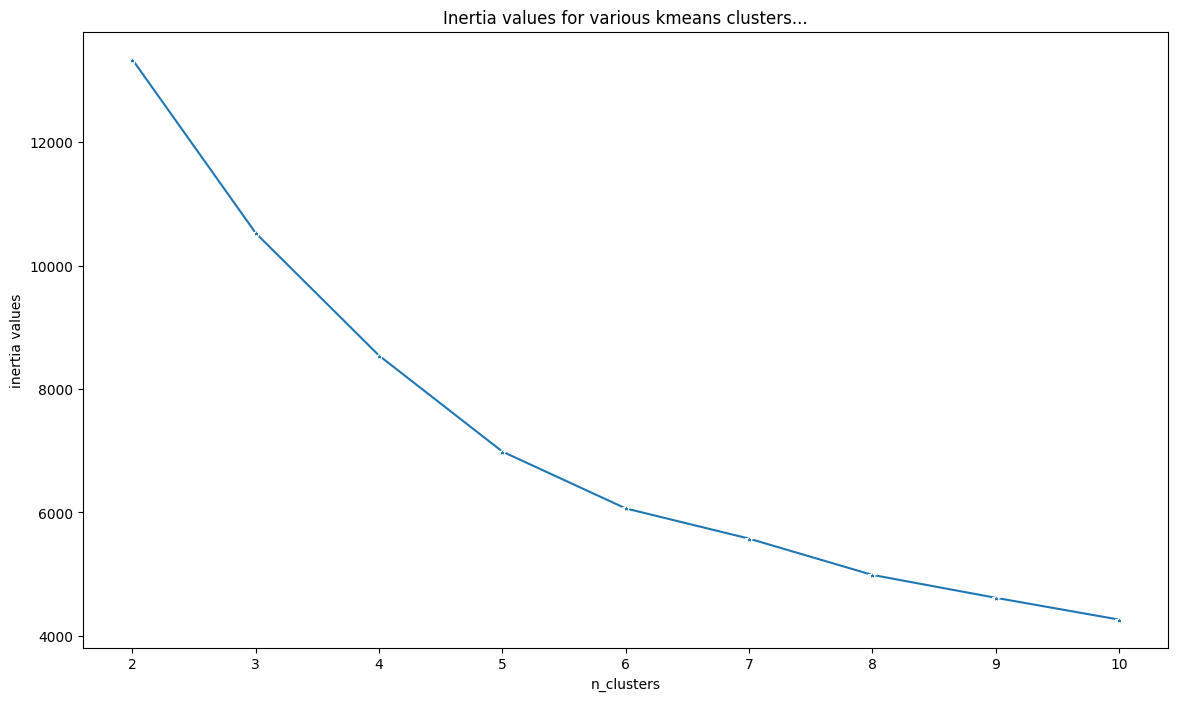

In [290]:
plt.figure(figsize=(14,8))
sns.lineplot(x=values,y=inertia,marker='*')
plt.xlabel('n_clusters')
plt.ylabel('inertia values')
plt.title('Inertia values for various kmeans clusters...')
plt.show()

**To be precise on n_clusters to use, confirming using silhoutte scores**

In [291]:
from sklearn.metrics import silhouette_score

In [292]:
silh=[]

for i in values:
    Kmeans=KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(x_scaled)
    silh.append(silhouette_score(x_scaled,Kmeans.labels_))

silh

[0.24266727918614805,
 0.26895600421638904,
 0.27762382055414647,
 0.29328099577008115,
 0.27439654749663567,
 0.28279143106007165,
 0.2814129326587803,
 0.2680100915327875,
 0.27480481263699047]

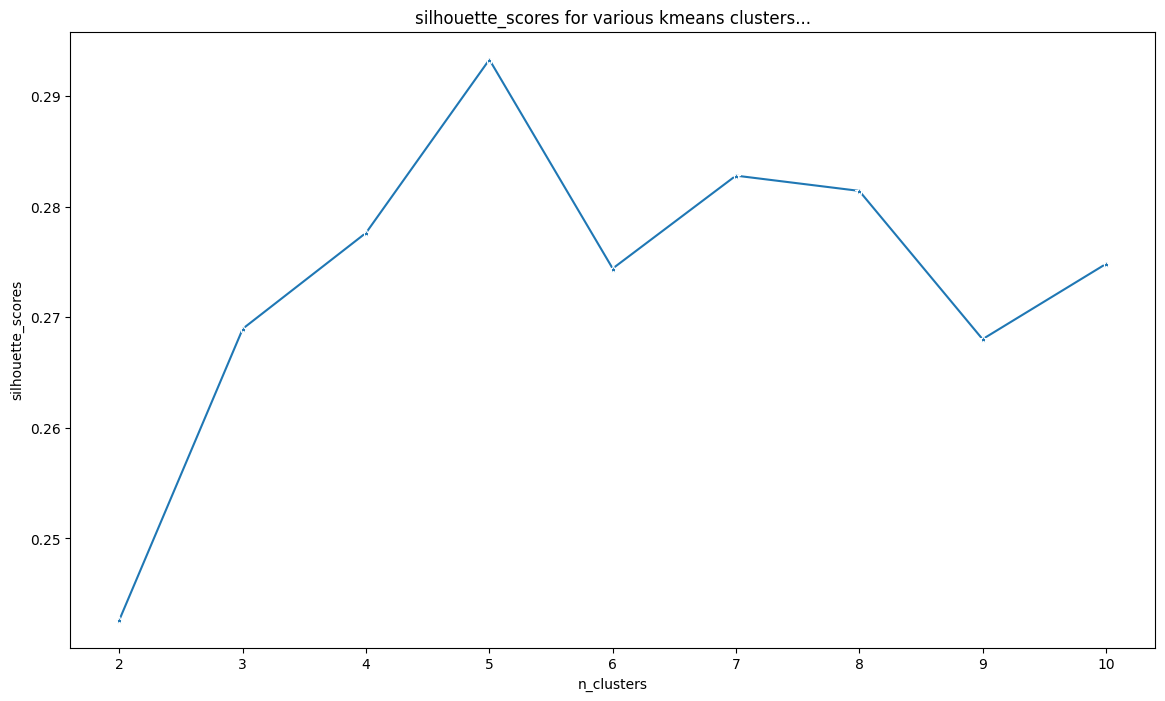

In [293]:
plt.figure(figsize=(14,8))
sns.lineplot(x=values,y=silh,marker='*')
plt.xlabel('n_clusters')
plt.ylabel('silhouette_scores')
plt.title('silhouette_scores for various kmeans clusters...')
plt.show()

**Based on the silhouette scores, the best n_clusters is 5**

In [327]:
kmeans=KMeans(n_clusters=5,random_state=42)
kmeans.fit(x_scaled)
km_preds=kmeans.predict(x_scaled)
len(km_preds)

4257

In [328]:
customer_segment_df['cluster']=km_preds
customer_df['cluster']=km_preds
customer_df

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency,churn,Segment,cluster
0,C10,2023-08-30,1,0.567068,0.567068,823,1,At-Risk Customer,0
1,C1000,2023-08-16,1,57.294811,57.294811,837,1,At-Risk Customer,0
2,C1002,2024-05-24,4,-508.832267,-127.208067,555,1,New Customer,2
3,C1005,2025-08-26,48,-60.088505,-1.251844,96,0,Loyal High-Value Customer,1
4,C1006,2024-02-10,1,-216.765751,-216.765751,659,1,At-Risk Customer,0
...,...,...,...,...,...,...,...,...,...
4252,C995,2025-05-19,18,4363.617284,242.423182,195,0,Loyal High-Value Customer,1
4253,C996,2025-05-28,1,-100.697044,-100.697044,186,0,New Customer,2
4254,C997,2025-08-09,1,42.519655,42.519655,113,0,New Customer,2
4255,C998,2024-02-28,1,-162.486539,-162.486539,641,1,At-Risk Customer,0


**Interpreting the cluster-- to get more out of just numbers**

In [329]:
cluster_summary=customer_df.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(2)

print(cluster_summary)

         recency  frequency  monetary
cluster                              
0         876.19       1.56   -157.88
1         185.85      37.82   3274.29
2         302.84       9.45   -537.60
3         195.38      49.31  -4389.13
4         540.86       3.95    561.33


In [330]:
# these cluster names are based on studying and evaluating the cluster summary above...
cluster_names={
    0: 'At-Risk Customer',
    1: 'Loyal High-Value Customer',
    2: 'New Customer',
    3: 'Discount Seeker Customer',
    4: 'Occassional Buyer Customer'
    
}

**Mapping cluster names to the data of customers**

In [331]:
customer_df['Segment']=customer_df['cluster'].map(cluster_names)

In [332]:
customer_df.head()

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency,churn,Segment,cluster
0,C10,2023-08-30,1,0.567068,0.567068,823,1,At-Risk Customer,0
1,C1000,2023-08-16,1,57.294811,57.294811,837,1,At-Risk Customer,0
2,C1002,2024-05-24,4,-508.832267,-127.208067,555,1,New Customer,2
3,C1005,2025-08-26,48,-60.088505,-1.251844,96,0,Loyal High-Value Customer,1
4,C1006,2024-02-10,1,-216.765751,-216.765751,659,1,At-Risk Customer,0


In [333]:
customer_df['Segment'].value_counts()

Segment
New Customer                  1576
Occassional Buyer Customer    1217
At-Risk Customer              1025
Loyal High-Value Customer      277
Discount Seeker Customer       162
Name: count, dtype: int64

In [334]:
customer_df=customer_df.drop(columns=['cluster'])

In [335]:
customer_df.head()

,customer_id,last_purchase,frequency,monetary,avg_order_value,recency,churn,Segment
0,C10,2023-08-30,1,0.567068,0.567068,823,1,At-Risk Customer
1,C1000,2023-08-16,1,57.294811,57.294811,837,1,At-Risk Customer
2,C1002,2024-05-24,4,-508.832267,-127.208067,555,1,New Customer
3,C1005,2025-08-26,48,-60.088505,-1.251844,96,0,Loyal High-Value Customer
4,C1006,2024-02-10,1,-216.765751,-216.765751,659,1,At-Risk Customer


In [336]:
customer_df.to_csv('aggregated_customer_data.csv')

**Saving the model!!**

In [337]:
import joblib

In [338]:
joblib.dump(lr,'churn_model_lr.pkl')

['churn_model_lr.pkl']

**Getting feature importance of logistic regression using coefficients**

In [48]:
importances= pd.DataFrame({
    'feature': x.columns,
    'coefficients': lr.coef_[0]
})

importances['abs_coeff']=importances['coefficients'].abs()
importances=importances.sort_values(by='abs_coeff',ascending=False)

print(importances)

           feature  coefficients  abs_coeff
0        frequency     -2.050558   2.050558
1         monetary      0.006178   0.006178
2  avg_order_value     -0.002722   0.002722


In [49]:
importances.to_csv('lr_model(feature_importances).csv')

In [53]:
insights={'Segment': ['New Customer','At-Risk Customer','Loyal High-Value Customer'],
          'Risk': ['Medium','High','Low'],
          'Recommended Actions': ['Onboarding','Re-engagement campaigns','Loyalty Rewards']
         }

actionable_insights_df=pd.DataFrame(insights)
actionable_insights_df.to_csv('actionable_insights.csv')